# StegnoGraphy

In [ ]:
!pip install torch torchvision scikit-image matplotlib tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm

In [ ]:
!tar -xzvf '/content/drive/MyDrive/LabelMe-12-50k.tar.gz' -C /content/

Streaming output truncated to the last 5000 lines.
train/0004/004126.jpg
train/0004/004125.jpg
train/0004/004124.jpg
train/0004/004123.jpg
train/0004/004122.jpg
train/0004/004121.jpg
train/0004/004120.jpg
train/0004/004119.jpg
train/0004/004118.jpg
train/0004/004117.jpg
train/0004/004116.jpg
train/0004/004115.jpg
train/0004/004114.jpg
train/0004/004113.jpg
train/0004/004112.jpg
train/0004/004111.jpg
train/0004/004110.jpg
train/0004/004109.jpg
train/0004/004108.jpg
train/0004/004107.jpg
train/0004/004106.jpg
train/0004/004105.jpg
train/0004/004104.jpg
train/0004/004103.jpg
train/0004/004102.jpg
train/0004/004101.jpg
train/0004/004100.jpg
train/0004/004099.jpg
train/0004/004098.jpg
train/0004/004097.jpg
train/0004/004096.jpg
train/0004/004095.jpg
train/0004/004094.jpg
train/0004/004093.jpg
train/0004/004092.jpg
train/0004/004091.jpg
train/0004/004090.jpg
train/0004/004089.jpg
train/0004/004088.jpg
train/0004/004087.jpg
train/0004/004086.jpg
train/0004/004085.jpg
train/0004/004084.jpg
tra

In [ ]:
train_root = '/content/train'
test_root = '/content/test'

# Recursively get .jpg images in each folder
def collect_images(root_dir):
    image_list = []
    for subdir, _, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith('jpg'):
                image_list.append(os.path.join(subdir, file))
    return image_list

train_images = collect_images(train_root)
test_images = collect_images(test_root)

print(f"Train images: {len(train_images)}, Test images: {len(test_images)}")


In [ ]:
val_split = 0.1
n_val = int(len(train_images) * val_split)
val_images = random.sample(train_images, n_val)
train_images = [img for img in train_images if img not in val_images]

print(f"Train set: {len(train_images)}, Val set: {len(val_images)}")


Train set: 36000, Val set: 4000


In [ ]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

class FlatImagePairDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        cover_path = self.image_paths[idx]
        secret_idx = random.randint(0, len(self.image_paths) - 1)
        while secret_idx == idx:
            secret_idx = random.randint(0, len(self.image_paths) - 1)
        secret_path = self.image_paths[secret_idx]
        cover_img = Image.open(cover_path).convert('RGB')
        secret_img = Image.open(secret_path).convert('RGB')
        if self.transform:
            cover_img = self.transform(cover_img)
            secret_img = self.transform(secret_img)
        return cover_img, secret_img


In [ ]:
train_dataset = FlatImagePairDataset(train_images, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

if val_images:
    val_dataset = FlatImagePairDataset(val_images, transform=transform)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
else:
    val_loader = None


In [ ]:
def display_results(generator, extractor, loader, device, num_examples=3):
    generator.eval()
    extractor.eval()
    with torch.no_grad():
        batch = next(iter(loader))
        covers, secrets = batch[0][:num_examples].to(device), batch[1][:num_examples].to(device)
        stegos = generator(covers, secrets)
        extracted = extractor(stegos)

        for i in range(num_examples):
            cover_np = (covers[i].cpu() + 1) / 2       #[-1,1]->[0,1]
            secret_np = (secrets[i].cpu() + 1) / 2
            stego_np = (stegos[i].cpu() + 1) / 2
            extracted_np = (extracted[i].cpu() + 1) / 2
            diff_stego_cover = torch.abs(stego_np - cover_np) * 20
            diff_extracted_secret = torch.abs(extracted_np - secret_np) * 20

            cover_arr = cover_np.permute(1, 2, 0).numpy()  #(c,h,w)->(h,w,c)
            secret_arr = secret_np.permute(1, 2, 0).numpy()
            stego_arr = stego_np.permute(1, 2, 0).numpy()
            extracted_arr = extracted_np.permute(1, 2, 0).numpy()

            psnr_stego = psnr(cover_arr, stego_arr)
            ssim_stego = ssim(cover_arr, stego_arr, channel_axis=2, data_range=1.0)
            psnr_extract = psnr(secret_arr, extracted_arr)
            ssim_extract = ssim(secret_arr, extracted_arr, channel_axis=2, data_range=1.0)

            fig, axs = plt.subplots(1, 6, figsize=(24,4))
            axs[0].imshow(cover_arr)
            axs[0].set_title('Cover')
            axs[1].imshow(secret_arr)
            axs[1].set_title('Secret')
            axs[2].imshow(stego_arr)
            axs[2].set_title(f'Stego\nPSNR:{psnr_stego:.2f}, SSIM:{ssim_stego:.3f}')
            axs[3].imshow(extracted_arr)
            axs[3].set_title(f'Extracted Secret\nPSNR:{psnr_extract:.2f}, SSIM:{ssim_extract:.3f}')
            axs[4].imshow(np.mean(diff_stego_cover.permute(1, 2, 0).numpy(), axis=2), cmap='hot')
            axs[4].set_title('Diff Stego-Cover')
            axs[5].imshow(np.mean(diff_extracted_secret.permute(1, 2, 0).numpy(), axis=2), cmap='hot')
            axs[5].set_title('Diff Extracted-Secret')
            plt.show()
            plt.close()


In [ ]:
def save_checkpoint(generator, discriminator, extractor, opt_g, opt_d, opt_e, epoch, path):
    torch.save({
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'extractor': extractor.state_dict(),
        'opt_g': opt_g.state_dict(),
        'opt_d': opt_d.state_dict(),
        'opt_e': opt_e.state_dict(),
        'epoch': epoch
    }, path)
    print(f"Checkpoint saved: {path}")


def load_checkpoint(checkpoint_path, device):
    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    extractor = Extractor().to(device)
    opt_g = optim.Adam(generator.parameters(), lr=0.0002)
    opt_d = optim.Adam(discriminator.parameters(), lr=0.0002)
    opt_e = optim.Adam(extractor.parameters(), lr=0.0002)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint['generator'])
    discriminator.load_state_dict(checkpoint['discriminator'])
    extractor.load_state_dict(checkpoint['extractor'])
    opt_g.load_state_dict(checkpoint['opt_g'])
    opt_d.load_state_dict(checkpoint['opt_d'])
    opt_e.load_state_dict(checkpoint['opt_e'])
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    return generator, discriminator, extractor, opt_g, opt_d, opt_e


In [ ]:
class Generator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        # Encoder for cover image
        self.cover_enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True))
        self.cover_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True))
        self.cover_enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True))

        # Encoder for secret image
        self.secret_enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True))
        self.secret_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True))
        self.secret_enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True))

        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True))

        # Decoder with skip connections Unet
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True))
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, 4, 2, 1),  # 256 because of skip connection
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True))
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(128, 32, 4, 2, 1),   # 128 because of skip connection
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True))
        self.final = nn.Sequential(
            nn.Conv2d(32, in_channels, 3, 1, 1),
            nn.Tanh())

    def forward(self, cover, secret):
        # Encode cover image
        c1 = self.cover_enc1(cover)
        c2 = self.cover_enc2(c1)
        c3 = self.cover_enc3(c2)

        # Encode secret image
        s1 = self.secret_enc1(secret)
        s2 = self.secret_enc2(s1)
        s3 = self.secret_enc3(s2)

        # Fuse features
        fused = torch.cat([c3, s3], dim=1)
        fused = self.fusion(fused)

        # Decode with skip connections (preserve cover structure)
        d1 = self.dec1(fused)
        d1 = torch.cat([d1, c2], dim=1)  # Skip connection

        d2 = self.dec2(d1)
        d2 = torch.cat([d2, c1], dim=1)  # Skip connection

        d3 = self.dec3(d2)
        output = self.final(d3)

        return output


class Extractor(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True))
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True))
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True))
        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True))

        # Decoder
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True))
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(512, 128, 4, 2, 1),  # 512 from skip connection
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True))
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, 4, 2, 1),   # 256 from skip connection
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True))
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(128, in_channels, 4, 2, 1),  # 128 from skip connection
            nn.Tanh())

    def forward(self, stego):
        e1 = self.enc1(stego)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Decoder with skip connections
        d1 = self.dec1(e4)
        d1 = torch.cat([d1, e3], dim=1)

        d2 = self.dec2(d1)
        d2 = torch.cat([d2, e2], dim=1)

        d3 = self.dec3(d2)
        d3 = torch.cat([d3, e1], dim=1)

        d4 = self.dec4(d3)
        return d4

class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid())

    def forward(self, img):
        return self.model(img).view(-1, 1)



In [ ]:
def train_gan(config):
    device = torch.device(config['device'])
    print(f'Using device: {device}')

    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    extractor = Extractor().to(device)

    opt_g = optim.Adam(generator.parameters(), lr=config['lr'], betas=(0.5, 0.999))
    opt_d = optim.Adam(discriminator.parameters(), lr=config['lr'], betas=(0.5, 0.999))
    opt_e = optim.Adam(extractor.parameters(), lr=config['lr'], betas=(0.5, 0.999))

    adv_loss = nn.BCELoss()
    recon_loss = nn.MSELoss()
    l1_loss = nn.L1Loss()

    train_loader = config['train_loader']
    val_loader = config['val_loader']

    train_d_losses, train_g_losses, train_e_losses = [], [], []
    val_losses, val_psnrs, val_ssims = [], [], []

    for epoch in range(config['epochs']):
        generator.train()
        discriminator.train()
        extractor.train()
        d_loss_sum, g_loss_sum, e_loss_sum = 0, 0, 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']}", leave=False)

        for covers, secrets in progress_bar:
            covers, secrets = covers.to(device), secrets.to(device)
            batch_size = covers.size(0)

            # Train discriminator
            opt_d.zero_grad()
            real_preds = discriminator(covers)
            real_labels = torch.ones_like(real_preds) * 0.9  # Label smoothing

            fake_stegos = generator(covers, secrets).detach()
            fake_preds = discriminator(fake_stegos)
            fake_labels = torch.zeros_like(fake_preds) + 0.1  # Label smoothing

            d_loss = (adv_loss(real_preds, real_labels) +
                     adv_loss(fake_preds, fake_labels)) / 2
            d_loss.backward()
            opt_d.step()
            d_loss_sum += d_loss.item()

            # generator and extractor jointly trained
            opt_g.zero_grad()
            opt_e.zero_grad()

            stegos = generator(covers, secrets)
            extracted_secrets = extractor(stegos)

            # Generator losses
            g_adv = adv_loss(discriminator(stegos), torch.ones_like(real_preds))
            g_cover_recon = l1_loss(stegos, covers)
            g_secret_recon = l1_loss(extracted_secrets, secrets)  #Ensure secret is recoverable


            g_loss = (g_adv +
                     config['lambda_cover'] * g_cover_recon +
                     config['lambda_secret'] * g_secret_recon)

            # Extractor loss
            e_loss = recon_loss(extracted_secrets, secrets)

            # Total loss for joint training
            total_loss = g_loss + e_loss
            total_loss.backward()
            opt_g.step()
            opt_e.step()

            g_loss_sum += g_loss.item()
            e_loss_sum += e_loss.item()

            progress_bar.set_postfix({
                'D_loss': f"{d_loss.item():.4f}",
                'G_loss': f"{g_loss.item():.4f}",
                'E_loss': f"{e_loss.item():.4f}"
            })

        print(f"Epoch {epoch+1}/{config['epochs']} - D Loss: {d_loss_sum/len(train_loader):.4f}, " +
              f"G Loss: {g_loss_sum/len(train_loader):.4f}, E Loss: {e_loss_sum/len(train_loader):.4f}")

        train_d_losses.append(d_loss_sum / len(train_loader))
        train_g_losses.append(g_loss_sum / len(train_loader))
        train_e_losses.append(e_loss_sum / len(train_loader))

        if val_loader is not None:
            val_loss, val_psnr, val_ssim = validate_gan(generator, extractor, val_loader, device)
            val_losses.append(val_loss)
            val_psnrs.append(val_psnr)
            val_ssims.append(val_ssim)

        if (epoch + 1) % 5 == 0 or epoch == config['epochs'] - 1:
            save_checkpoint(generator, discriminator, extractor, opt_g, opt_d, opt_e, epoch+1,
                          f'improved_checkpoint_epoch_{epoch+1}.pth')

    plt.figure()
    plt.plot(train_d_losses, label='Train Discriminator Loss')
    plt.plot(train_g_losses, label='Train Generator Loss')
    plt.plot(train_e_losses, label='Train Extractor Loss')
    if val_losses:
        plt.plot(val_losses, label='Validation Extractor Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')
    plt.show()

    plt.figure()
    plt.plot(val_psnrs, label='Validation PSNR')
    plt.plot(val_ssims, label='Validation SSIM')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.legend()
    plt.title('Validation PSNR and SSIM')
    plt.show()

def validate_gan(generator, extractor, val_loader, device):
    generator.eval()
    extractor.eval()
    recon_loss = nn.MSELoss()
    total_loss, psnr_scores, ssim_scores = 0, [], []

    with torch.no_grad():
        for covers, secrets in val_loader:
            covers, secrets = covers.to(device), secrets.to(device)
            stegos = generator(covers, secrets)
            extracted = extractor(stegos)
            total_loss += recon_loss(extracted, secrets).item()

            for i in range(covers.size(0)):
                secret_np = (secrets[i].cpu() + 1) / 2
                extracted_np = (extracted[i].cpu() + 1) / 2
                secret_arr = secret_np.permute(1,2,0).numpy()
                extracted_arr = extracted_np.permute(1,2,0).numpy()
                psnr_scores.append(psnr(secret_arr, extracted_arr))
                ssim_scores.append(ssim(secret_arr, extracted_arr,
                                      channel_axis=2, data_range=1.0))

    print(f'Validation loss: {total_loss/len(val_loader):.4f}, ' +
      f'PSNR: {np.mean(psnr_scores):.3f}, SSIM: {np.mean(ssim_scores):.3f}')
    return total_loss/len(val_loader), np.mean(psnr_scores), np.mean(ssim_scores)




In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Using device: cuda


Epoch 1/5 - D Loss: 0.6314, G Loss: 2.7398, E Loss: 0.0420


Validation loss: 0.0380, PSNR: 20.628, SSIM: 0.647


Epoch 2/5 - D Loss: 0.5411, G Loss: 2.9008, E Loss: 0.0307


Validation loss: 0.0488, PSNR: 19.647, SSIM: 0.600


...

Validation loss: 0.0243, PSNR: 22.862, SSIM: 0.653


Epoch 4/5 - D Loss: 0.5738, G Loss: 2.5333, E Loss: 0.0245


Validation loss: 0.0193, PSNR: 24.060, SSIM: 0.705


Epoch 5/5 - D Loss: 0.5612, G Loss: 2.4891, E Loss: 0.0211


Validation loss: 0.0192, PSNR: 24.121, SSIM: 0.724
Checkpoint saved: improved_checkpoint_epoch_5.pth


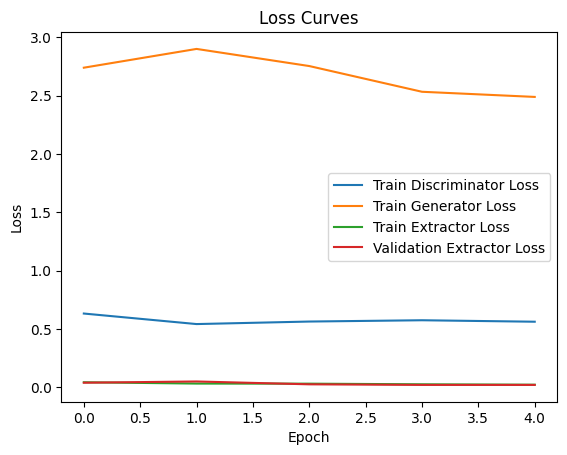

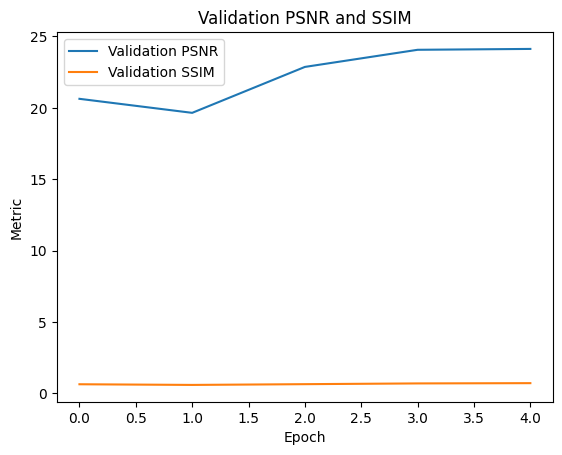

In [ ]:
config = {
    'train_loader': train_loader,
    'val_loader': val_loader,
    'lr': 0.0002,
    'epochs': 5,
    'lambda_cover': 1.0,     # Weight for cover reconstruction
    'lambda_secret': 10.0,   # Weight for secret reconstruction
    'device': device
}
train_gan(config)

In [ ]:
generator, _, extractor, _, _, _ = load_checkpoint('improved_checkpoint_epoch_5.pth', device)

Loaded checkpoint from epoch 5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


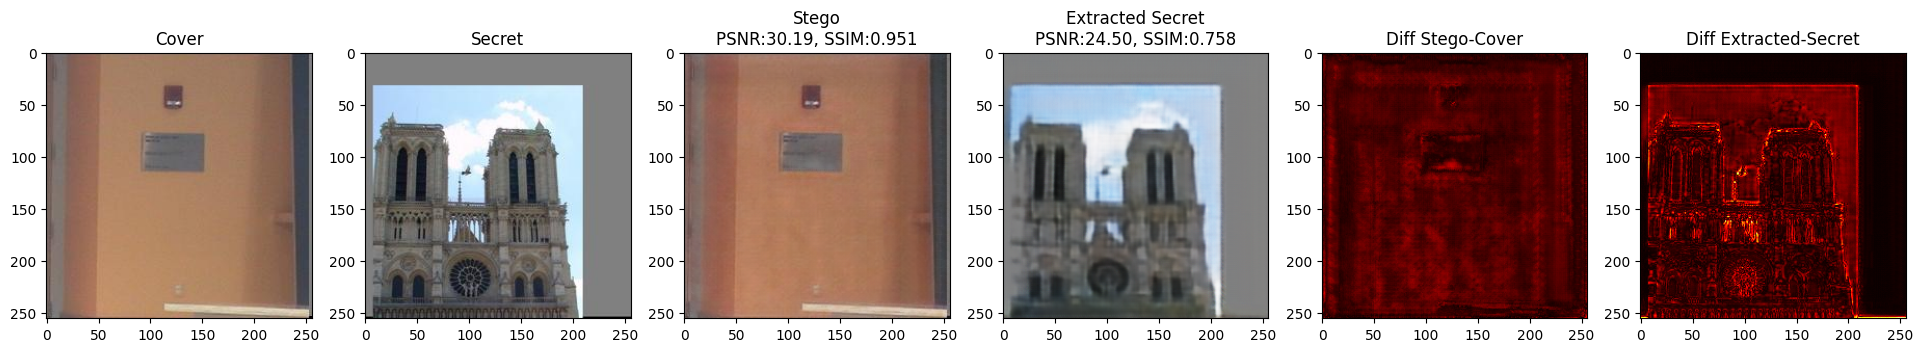

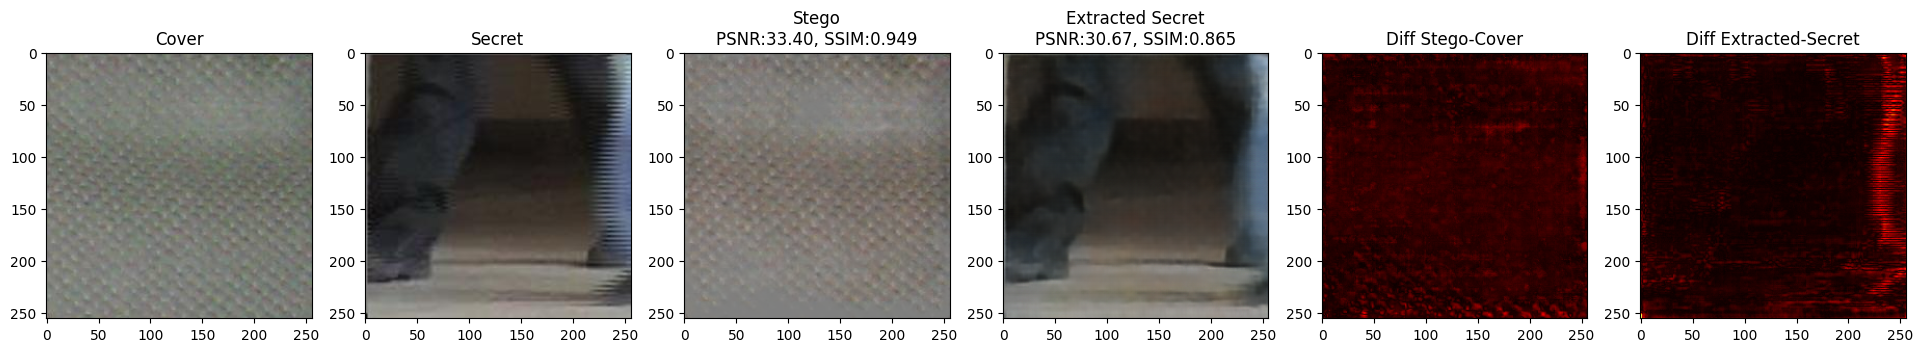

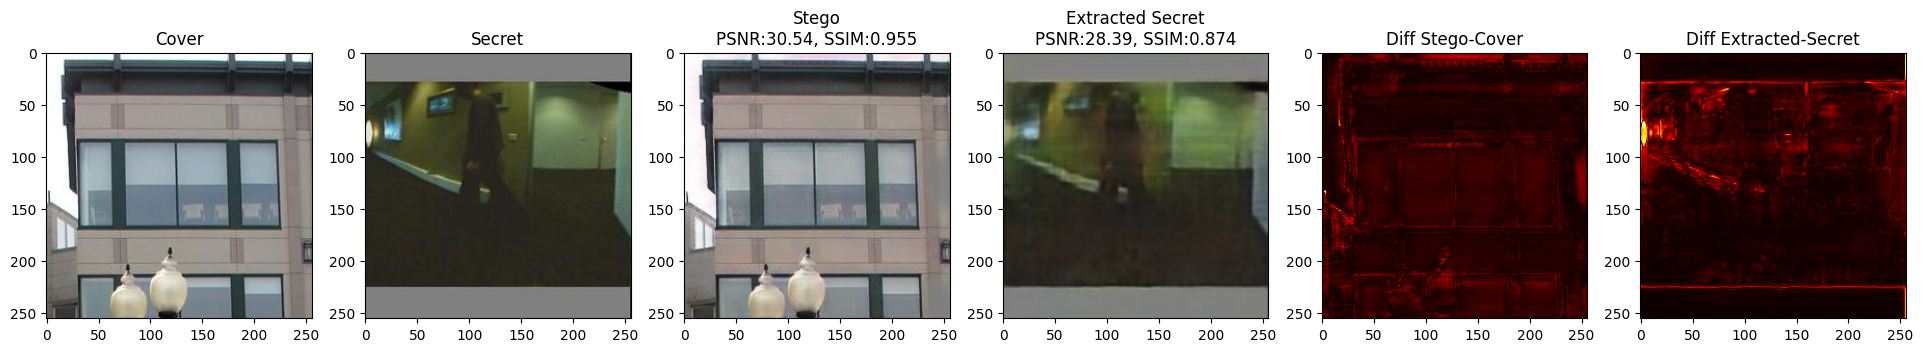

In [ ]:
display_results(generator, extractor, train_loader, device)

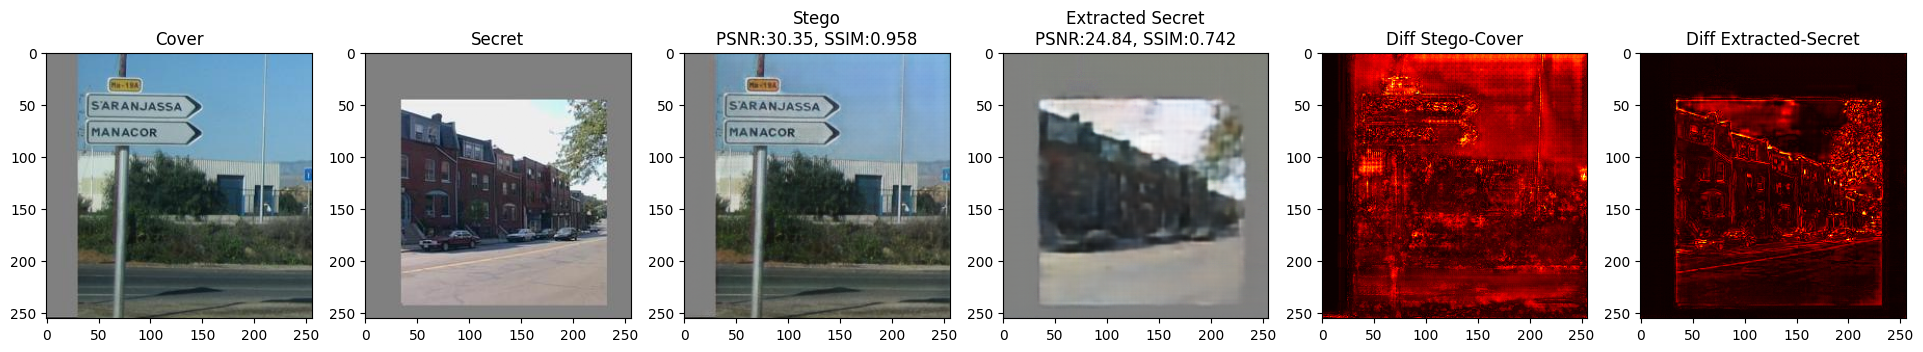

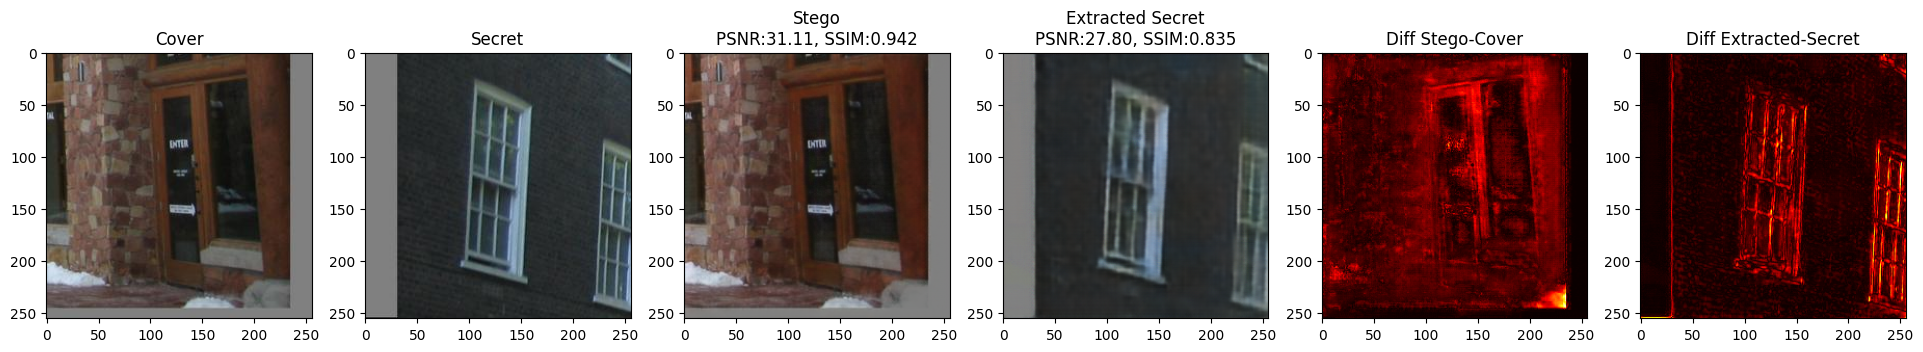

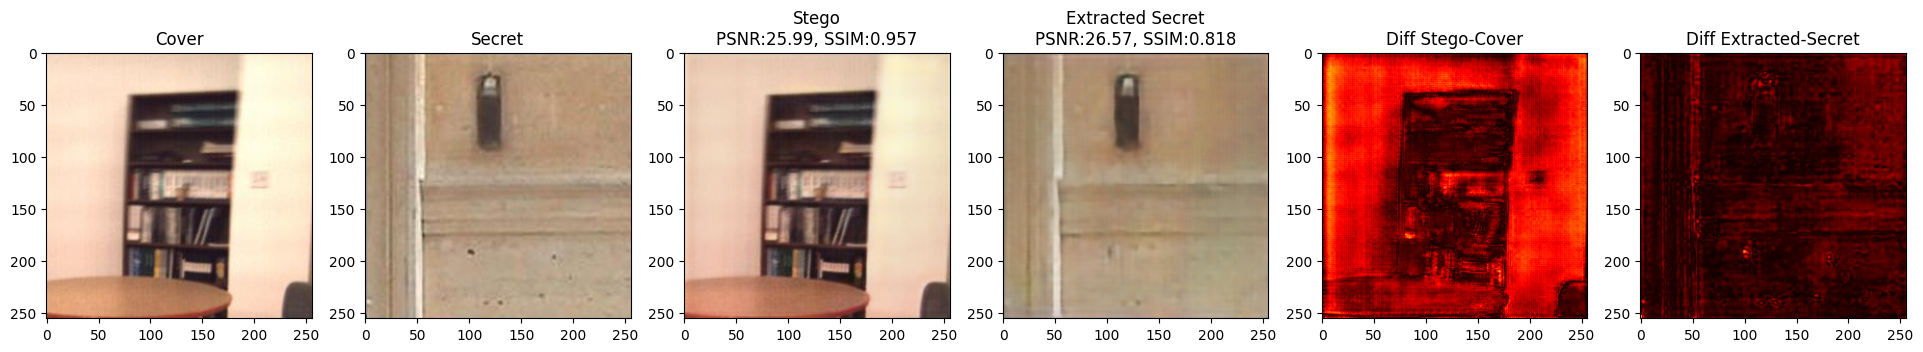

In [ ]:
test_dataset = FlatImagePairDataset(test_images, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
display_results(generator, extractor,test_loader,device)


In [ ]:
def evaluate_on_test(generator, extractor, test_loader, device):
    generator.eval()
    extractor.eval()
    recon_loss = nn.MSELoss()
    total_loss = 0
    psnr_scores, ssim_scores = [], []

    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc="Evaluating Test Set")
        for covers, secrets in progress_bar:
            covers, secrets = covers.to(device), secrets.to(device)
            stegos = generator(covers, secrets)
            extracted = extractor(stegos)

            loss = recon_loss(extracted, secrets).item()
            total_loss += loss

            batch_psnr = []
            batch_ssim = []
            for i in range(covers.size(0)):
                secret_np = (secrets[i].cpu() + 1) / 2
                extracted_np = (extracted[i].cpu() + 1) / 2
                secret_arr = secret_np.permute(1, 2, 0).numpy()
                extracted_arr = extracted_np.permute(1, 2, 0).numpy()
                batch_psnr.append(psnr(secret_arr, extracted_arr))
                batch_ssim.append(ssim(secret_arr, extracted_arr, channel_axis=2, data_range=1.0))
            psnr_scores.extend(batch_psnr)
            ssim_scores.extend(batch_ssim)

            progress_bar.set_postfix({
                "Batch Loss": f"{loss:.4f}",
                "Avg PSNR": f"{np.mean(psnr_scores):.3f}",
                "Avg SSIM": f"{np.mean(ssim_scores):.3f}",
            })

    print(f"\nTest Loss: {total_loss/len(test_loader):.4f}")
    print(f"Average PSNR: {np.mean(psnr_scores):.3f}")
    print(f"Average SSIM: {np.mean(ssim_scores):.3f}")


generator, _, extractor, _, _, _ = load_checkpoint('improved_checkpoint_epoch_5.pth', device)
evaluate_on_test(generator, extractor, test_loader, device)


Loaded checkpoint from epoch 5


Evaluating Test Set: 100%|██████████| 2500/2500 [03:53<00:00, 10.71it/s, Batch Loss=0.0322, Avg PSNR=24.036, Avg SSIM=0.720]


Test Loss: 0.0192
Average PSNR: 24.036
Average SSIM: 0.720
